#04-ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

¿Cuál es el propósito de PCA aquí?
Reducir la dimensionalidad del dataset de usuarios de streaming, transformando las variables numéricas correlacionadas en un nuevo conjunto de variables independientes (componentes principales). Esto nos permitirá resumir la información de los usuarios (como edad, tiempo de visualización y soporte) en menos variables sin perder información clave, facilitando análisis posteriores como la segmentación (clustering).

Selección de Variables y Escalamiento
PCA solo funciona con variables numéricas continuas. Mirando tu dataset streaming_users_clean.csv, las variables candidatas son:

age (Edad)

monthly_watch_time_mins (Tiempo de reproducción mensual)

customer_support_tickets (Tickets de soporte)

¿Por qué es crítico el escalamiento?
PCA es extremadamente sensible a las escalas. monthly_watch_time_mins tiene valores en cientos o miles, mientras que customer_support_tickets tiene valores de 0 a 5. Si no escalamos, la variable del tiempo de reproducción dominará por completo los componentes solo por su magnitud. Usaremos StandardScaler para que todas tengan media 0 y varianza 1.

In [5]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar el dataset
streaming_users= pd.read_csv( r"C:\Users\jorge leandro\OneDrive\Desktop\proyecto_final_md\data\processed\streaming_users_clean.csv"
)

# 2. Seleccionar solo las variables numéricas para PCA
features = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
X = streaming_users[features]

# 3. Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados correctamente.")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Datos escalados correctamente.


Aplicación de PCA y Varianza Explicada
Ahora aplicamos PCA. Como tenemos 3 variables, inicialmente calculamos las 3 componentes posibles para evaluar cuánta información retiene cada una mediante la varianza explicada acumulada.

In [6]:
# 4. Ajustar PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 5. Analizar la varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Mostrar en un DataFrame para el informe
df_variance = pd.DataFrame({
    'Componente Principal': [f'PC{i+1}' for i in range(3)],
    'Varianza Explicada': explained_variance,
    'Varianza Acumulada': cumulative_variance
})
print(df_variance)

  Componente Principal  Varianza Explicada  Varianza Acumulada
0                  PC1            0.339539            0.339539
1                  PC2            0.333278            0.672817
2                  PC3            0.327183            1.000000


Gráfico de Codo (Scree Plot) para documentar
Es buena práctica incluir este gráfico para justificar con cuántas componentes te vas a quedar (generalmente se busca superar el 70-80% de la varianza explicada)

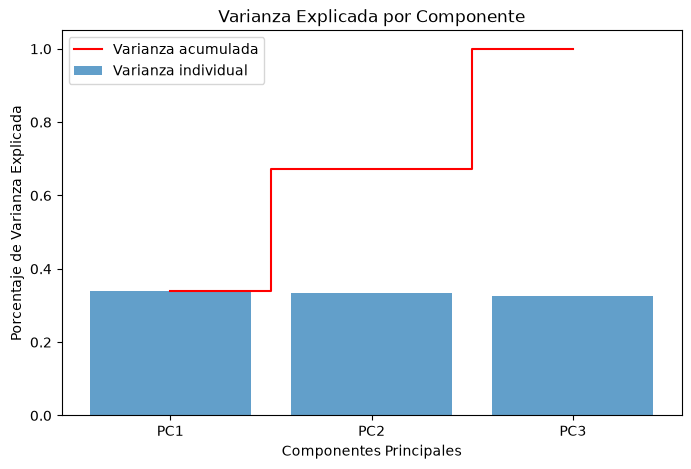

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 4), explained_variance, alpha=0.7, align='center', label='Varianza individual')
plt.step(range(1, 4), cumulative_variance, where='mid', label='Varianza acumulada', color='red')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xlabel('Componentes Principales')
plt.xticks([1, 2, 3], ['PC1', 'PC2', 'PC3'])
plt.legend(loc='best')
plt.title('Varianza Explicada por Componente')
plt.show()

Interpretación de las Componentes (Loadings)
Para explicar qué significa cada componente, debemos mirar los loadings (las cargas o pesos que tiene cada variable original en la componente).

In [8]:
# 6. Obtener la matriz de carga (loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(3)], 
    index=features
)
print("Matriz de Loadings:")
print(loadings)

Matriz de Loadings:
                               PC1       PC2       PC3
age                       0.099798  0.994438 -0.033677
monthly_watch_time_mins   0.702398 -0.094382 -0.705500
customer_support_tickets  0.704754 -0.046753  0.707910


La PC1 representa el nivel de actividad y fricción del usuario. Valores altos en esta componente identifican a usuarios que consumen mucho contenido pero que también demandan mucho soporte técnico.


Estructura sugerida para el texto en tu Notebook:
Título: ## Etapa 04 - Análisis de Componentes Principales (PCA)

Propósito: Texto breve explicando por qué se reduce la dimensionalidad.

Variables utilizadas: Lista detallada (age, monthly_watch_time_mins, customer_support_tickets) y justificación del uso de StandardScaler.

Celda de Código: Bloque de código de escalamiento y ajuste de PCA.

Resultados de Varianza: Explicación textual de los dataframes obtenidos (ej: "Se observa que las dos primeras componentes explican el X% de la variabilidad total...").

Interpretación: Texto que defina el "perfil" o significado que tomó cada PC basándose en los pesos (loadings).